### Wind farm power forecasting
This short notebook attempts to demonstrate a few basic concepts in data processing and machine learning. 
- Parsing and analyzing data
- Predicting power with a "persistence model" and a machine learning model (support vector machine).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from data_io import load_data
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from data_parsing import parse_data
from sklearn import svm
from sklearn.model_selection import TimeSeriesSplit
import warnings 
warnings.filterwarnings("ignore")

##### 1- Load and parse data

In [2]:
# Load files
files = [
    './inputs/Location1_train.csv', 
    './inputs/Location2_train.csv', 
    './inputs/Location3_train.csv', 
    './inputs/Location4_train.csv'
]

data = load_data(files)

Combined DataFrame Shape: (140160, 15)

First 5 rows:
                 Time  temperature_2m  relativehumidity_2m  dewpoint_2m  \
0 2017-01-02 00:00:00      271.205556                   85   268.983333   
1 2017-01-02 01:00:00      271.150000                   86   269.094444   
2 2017-01-02 02:00:00      270.261111                   91   268.983333   
3 2017-01-02 03:00:00      270.594444                   88   268.872222   
4 2017-01-02 04:00:00      270.538889                   88   268.761111   

   windspeed_10m  windspeed_100m  winddirection_10m  winddirection_100m  \
0           1.44            1.26                146                 162   
1           2.06            3.99                151                 158   
2           1.30            2.78                148                 150   
3           1.30            2.69                 58                 105   
4           2.47            4.43                 58                  84   

   windgusts_10m   Power   Location  wdcos_1

In [3]:
# Check for abnormal values (parsing data)
data_p = parse_data(data)

#### 2- plot time series

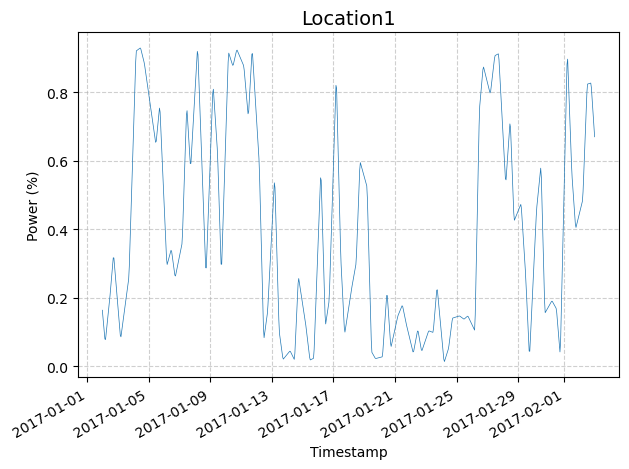

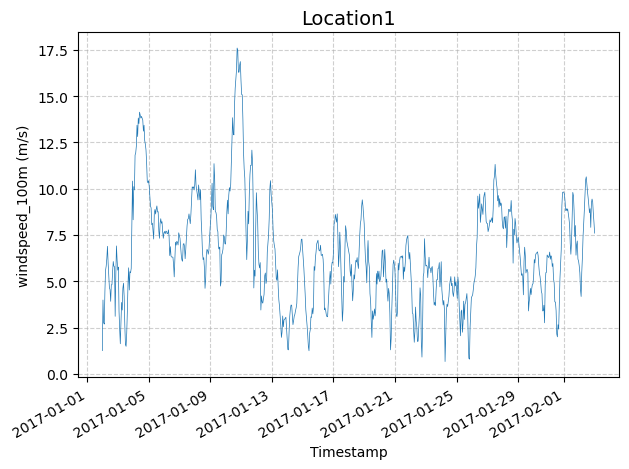

In [4]:
from plot_data import plot_location_data

Location = 'Location1'
time_s = '2017-01-02 00:00:00'
time_f = '2017-02-02 23:00:00'

plot_location_data(data_p,'Power',Location, time_s, time_f)
plot_location_data(data_p,'windspeed_100m',Location, time_s, time_f)

3- Persistence model

In [10]:
# Multiindex definition
data = data_p.set_index(['Time', 'Location'])

In [14]:
from persistence_model import pm_model

location = 1
time = '20200703 23'
power = pm_model(data, location, time)

print("Predicted power is", power)

Predicted power is 0.1912


#### Analysis of the correlations between variables to set relevant features

<Axes: >

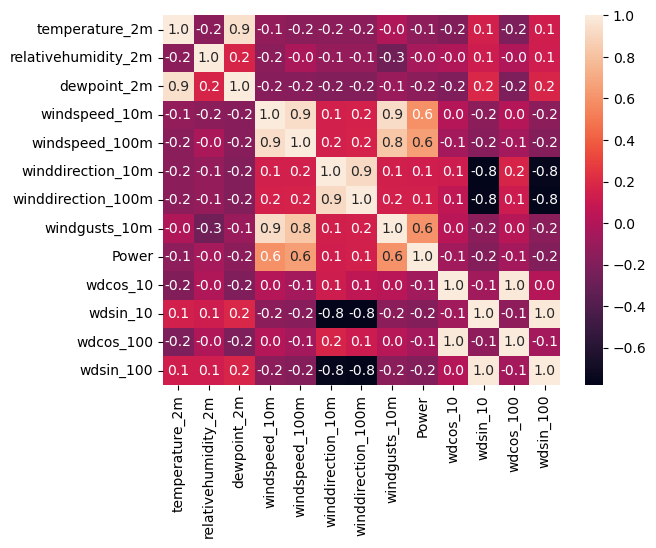

In [15]:
from data_split import split_df
import seaborn

correlation_matrix = data.corr(numeric_only = True)
seaborn.heatmap(correlation_matrix, annot = True, fmt = ".1f")

The correlation between power is only relevant in the case of wind speed (10 or 100m). We select wind speed at 100m for machine learning.

In [ ]:
# ML model

In [ ]:
# NN model